# GARDIAN: autonomous continual-learning NIDS, a Python implementation

This notebook implements the framework from

> H. Sami, C. Talhi, H. Ould-Slimane, A. Mourad, H. Otrok, J. Bentahar,
> **"Deep reinforcement learning for autonomous and continual network intrusion detection"**,
> *Journal of Information Security and Applications*, vol. 102, 104594, 2026.
> doi:10.1016/j.jisa.2026.104594

GARDIAN has two layers (paper Sec. 3, Figs. 1–2):

| Layer | Component | Paper | Section of this notebook |
|---|---|---|---|
| 1 | Multi-Head AutoEncoder (one shared encoder, one decoder per traffic class) flags samples with reconstruction error `RE ≥ th` | Sec. 3.1.1, Eqs. 1–3, Alg. 1 | §4 |
| 1 | DBSCAN on the encoder output + semi-supervised majority / nearest-neighbour labelling | Sec. 3.1.2, Alg. 2, Fig. 3 | §5 |
| – | Fusion rule between MAE and NID classifier | Sec. 3.2.4 | §6 |
| 2 | Memory (replay) buffer: per-class FIFO queue without duplicates | Sec. 3.2.2 | §7 |
| 2 | Conditional GAN (SPOCU generator) for samples of the new patterns, with diagnostics | Sec. 3.2.1, 4.3.1, Table 2, Fig. 7 | §8 |
| 2 | MDP: state `S=[S_B,S_P,S_N,N_min,N_max]`, action `A=[A_S,A_A]`, reward `R=R_P+R_E` | Sec. 3.2.3, Eqs. 4–8 | §9 |
| 2 | PPO agent that decides when and how much to fine-tune | Alg. 3, Sec. 4.2 | §10–11 |
| – | NID classifier: MLP 64-128-128-64, softmax | Sec. 3.2.4, 4.2 | §3 |
| – | Ablation: CGAN+buffer vs CGAN only vs buffer only | Sec. 4.3.4, Figs. 4–6 | §13 |
| – | Reward sensitivity over λ modes × β | Sec. 4.3.3, Table 4, Fig. 9 | §14 |

**Data.** The paper uses the NetFlow-v2 datasets (several GB). By default the notebook runs on the
UGRansome CSV already in this repository (`data/ugransome_final2.csv`, classes A / S / SS with
S = benign). Six ransomware families never appear during the initial training and arrive later as
the *emerging traffic pattern*. This matches the paper's case where a "new pattern belongs to an
existing family" (Sec. 3.2.3). Set `CFG["dataset"] = "netflow"` and point `CFG["netflow_csv"]` at an
NF-*-v2 CSV to run the domain-incremental setting of Table 5 instead (§2).

Everything runs on CPU in roughly 10 minutes with the default budget (4 cores).

## 1. Setup and configuration

In [1]:
import copy
import os
import sys
import time
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# Make the repo root importable whether the notebook is run from gardian/ or from the root.
ROOT = os.path.abspath(".." if os.path.basename(os.getcwd()) == "gardian" else ".")
sys.path.insert(0, ROOT)

CFG = dict(
    seed=42,
    dataset="ugransome",            # "ugransome" | "netflow"
    ugransome_csv=os.path.join(ROOT, "data/ugransome_final2.csv"),
    # Families held out from initial training -> they form the emerging pattern stream.
    ugransome_new_families=["APT", "EDA2", "Globe", "JigSaw", "Razy", "SamSam"],
    netflow_csv=os.path.join(ROOT, "data/NF-UQ-NIDS-v2.csv"),
    netflow_nrows=2_000_000,        # rows read from the (very large) NetFlow CSV
    netflow_classes=["Benign", "DoS", "DDoS", "Reconnaissance"],
    netflow_known_datasets=["NF-UNSW-NB15-v2", "NF-ToN-IoT-v2"],   # Table 5, S1 (train)
    netflow_new_datasets=["NF-BoT-IoT-v2", "NF-CSE-CIC-IDS2018-v2"],
    netflow_per_class_cap=20_000,
    unseen_cap=20_000,              # max emerging-pattern samples kept from the stream

    # NID classifier (Sec. 4.2)
    clf_hidden=(64, 128, 128, 64), clf_lr=1e-3, clf_epochs=10, clf_batch=256,
    finetune_lr=5e-4, finetune_epochs=1, finetune_batch=64,

    # Multi-Head AutoEncoder (Sec. 4.2)
    mae_epochs=20, mae_batch=256, mae_lr=1e-3, mae_l2=1e-4, mae_dropout=0.5,
    mae_threshold_quantile=0.95,    # th = this quantile of RE on known validation traffic

    # DBSCAN (paper: eps = 0.9 for its encodings; 0.9 merges everything into one cluster here, see §5)
    dbscan_eps=0.1, dbscan_min_samples=5, labeled_per_class=2000, knn_k=5,

    # Replay buffer (Sec. 4.3.4: 2000 samples per class)
    buffer_cap=2000, buffer_admit_conf=0.9, buffer_admit_per_round=50,

    # CGAN (Sec. 4.2 and the "early-stopped" configuration of Table 2)
    gan_noise=100, gan_hidden=128, gan_lr=2e-4, gan_batch=256,
    gan_pretrain_epochs=10, gan_finetune_epochs=4, gan_real_mix=0.5,

    # MDP / PPO (Sec. 3.2.3, 4.2)
    episode_len=10,                 # fine-tuning rounds per episode
    n_max_cap=500,                  # upper bound for N_A^max (per class, per source)
    n_init=(0, 100),                # initial (N_A^min, N_A^max)
    n_delta=50,                     # max |ΔN_A| per step
    reward_beta=0.005, reward_lambda="attack_priority",   # best setting of Table 4
    eval_known_per_class=1000,      # known-traffic samples in the reward evaluation set
    ppo_timesteps=3000, ppo_n_steps=100, ppo_batch=50, ppo_epochs=10,
    ppo_lr=3e-4, ppo_gamma=0.99, ppo_clip=0.2, ppo_log_std_init=-1.0,

    run_ablation=True,
    run_reward_sensitivity=False,   # 12 extra PPO runs; switch on if you have ~30 min
    sensitivity_timesteps=600,
)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(CFG["seed"])
torch.set_num_threads(max(1, os.cpu_count() or 1))
try:
    display
except NameError:                     # running as a plain script
    display = print
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__)

device: cpu | torch 2.14.1+cu130


## 2. Data and the continual-learning scenario

The scenario has four parts:

* **known**: traffic seen during the initial setup and calibration phase. It is split into
  *train* (classifier, MAE, CGAN, buffer seed), *val* (MAE threshold calibration and the
  known part of the RL evaluation set) and *test*.
* **new**: traffic from the emerging patterns, split into an unlabelled *stream* that goes
  through Layer 1 and a labelled *test* used only for the final report. GARDIAN never sees
  ground-truth labels of new traffic. It relies on the pseudo-labels produced by Layer 1.

In [2]:
def load_ugransome(cfg):
    df = pd.read_csv(cfg["ugransome_csv"]).dropna().reset_index(drop=True)
    # The Kaggle CSV keeps the typos "Protcol" / "SeddAddress"; addresses are identifiers -> dropped.
    numeric = ["Time", "Clusters", "BTC", "USD", "Netflow_Bytes", "Port"]
    categorical = ["Protcol", "Flag", "Threats", "Family"]
    # One-hot (not label) encoding: a never-seen family or flag then activates an input column that
    # was always 0 during training, which is what makes it an *emerging pattern* for the MAE.
    onehot = pd.get_dummies(df[categorical].astype(str), prefix=categorical, dtype=np.float64)
    feats = numeric + list(onehot.columns)
    X = np.hstack([df[numeric].to_numpy(dtype=np.float64), onehot.to_numpy()])
    class_names = ["A", "S", "SS"]           # S = benign (synthetic signature), A / SS = attacks
    y = df["Prediction"].map({c: i for i, c in enumerate(class_names)}).to_numpy()
    is_new = df["Family"].isin(cfg["ugransome_new_families"]).to_numpy()
    groups = [[feats.index(c) for c in onehot.columns if c.startswith(p + "_")] for p in categorical]
    return X, y, is_new, class_names, "S", feats, groups


def load_netflow(cfg):
    """NF-*-v2 CSV (e.g. NF-UQ-NIDS-v2 with its 'Dataset' column). Domain-incremental, Table 5 S1."""
    df = pd.read_csv(cfg["netflow_csv"], nrows=cfg["netflow_nrows"])
    df = df[df["Attack"].isin(cfg["netflow_classes"])]
    # Balance the read-in rows per (dataset, class) so that benign traffic does not dominate.
    df = (df.groupby(["Dataset", "Attack"], group_keys=False)
            .apply(lambda g: g.sample(min(len(g), cfg["netflow_per_class_cap"]),
                                      random_state=cfg["seed"])))
    drop = ["IPV4_SRC_ADDR", "IPV4_DST_ADDR", "L4_SRC_PORT", "L4_DST_PORT",
            "Label", "Attack", "Dataset"]
    feats = [c for c in df.columns if c not in drop]
    X = df[feats].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    X = np.log1p(X.fillna(0).clip(lower=0).to_numpy(dtype=np.float64))   # heavy-tailed counters
    class_names = list(cfg["netflow_classes"])
    y = df["Attack"].map({c: i for i, c in enumerate(class_names)}).to_numpy()
    is_new = df["Dataset"].isin(cfg["netflow_new_datasets"]).to_numpy()
    keep = is_new | df["Dataset"].isin(cfg["netflow_known_datasets"]).to_numpy()
    return X[keep], y[keep], is_new[keep], class_names, "Benign", feats, []


loader = load_ugransome if CFG["dataset"] == "ugransome" else load_netflow
X_all, y_all, is_new, CLASS_NAMES, BENIGN, FEATURES, ONEHOT_GROUPS = loader(CFG)
K = len(CLASS_NAMES)
BENIGN_ID = CLASS_NAMES.index(BENIGN)
rng = np.random.default_rng(CFG["seed"])

known_idx, new_idx = np.where(~is_new)[0], np.where(is_new)[0]
k_tr, k_rest = train_test_split(known_idx, test_size=0.3, random_state=CFG["seed"],
                                stratify=y_all[known_idx])
k_val, k_te = train_test_split(k_rest, test_size=0.5, random_state=CFG["seed"],
                               stratify=y_all[k_rest])
n_stream, n_te = train_test_split(new_idx, test_size=0.5, random_state=CFG["seed"],
                                  stratify=y_all[new_idx])
n_stream = rng.permutation(n_stream)[:CFG["unseen_cap"]]

# Min-Max to [0, 1], fitted on known training traffic only (the only data available at setup).
scaler = MinMaxScaler().fit(X_all[k_tr])
Xs = np.clip(scaler.transform(X_all), 0.0, 1.0).astype(np.float32)

Xk_tr, yk_tr = Xs[k_tr], y_all[k_tr]
Xk_val, yk_val = Xs[k_val], y_all[k_val]
Xk_te, yk_te = Xs[k_te], y_all[k_te]
Xn_stream, yn_stream_true = Xs[n_stream], y_all[n_stream]   # true labels: diagnostics only
Xn_te, yn_te = Xs[n_te], y_all[n_te]
D = Xs.shape[1]

summary = pd.DataFrame({
    "split": ["known/train", "known/val", "known/test", "new/stream (unlabelled)", "new/test"],
    "rows": [len(k_tr), len(k_val), len(k_te), len(n_stream), len(n_te)],
    **{c: [int((y_all[ix] == i).sum()) for ix in (k_tr, k_val, k_te, n_stream, n_te)]
       for i, c in enumerate(CLASS_NAMES)},
})
print(f"{K} classes {CLASS_NAMES} (benign = {BENIGN}), {D} features: {FEATURES[:8]} ...")
summary

3 classes ['A', 'S', 'SS'] (benign = S), 44 features: ['Time', 'Clusters', 'BTC', 'USD', 'Netflow_Bytes', 'Port', 'Protcol_ICMP', 'Protcol_TCP'] ...


,split,rows,A,S,SS
0,known/train,59258,16193,26559,16506
1,known/val,12698,3470,5691,3537
2,known/test,12699,3470,5692,3537
3,new/stream (unlabelled),20000,6073,8817,5110
4,new/test,32194,9714,14219,8261


## 3. NID classifier (Sec. 3.2.4, 4.2)

The classifier is an MLP with hidden layers 64-128-128-64 (ReLU), a softmax output, Adam and
sparse categorical cross-entropy. It is pretrained on known traffic only. Accuracy on the new
families before any adaptation is the starting point that GARDIAN has to improve.

In [3]:
class NIDClassifier(nn.Module):
    def __init__(self, d, k, hidden):
        super().__init__()
        layers, prev = [], d
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, k))      # softmax is folded into the cross-entropy loss
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_classifier(model, X, y, epochs, lr, batch, opt=None):
    opt = opt or torch.optim.Adam(model.parameters(), lr=lr)
    Xt, yt = torch.from_numpy(X), torch.from_numpy(y.astype(np.int64))
    model.train()
    for _ in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), batch):
            b = perm[i:i + batch]
            loss = F.cross_entropy(model(Xt[b]), yt[b])
            opt.zero_grad()
            loss.backward()
            opt.step()
    return opt


@torch.no_grad()
def predict_proba(model, X):
    model.eval()
    return F.softmax(model(torch.from_numpy(X)), dim=1).numpy()


def metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=range(K))
    rec = np.divide(np.diag(cm), cm.sum(1), out=np.zeros(K), where=cm.sum(1) > 0)
    return dict(acc=accuracy_score(y_true, y_pred),
                f1=f1_score(y_true, y_pred, average="macro", labels=range(K), zero_division=0),
                recall=rec, cm=cm)


def report(model, name):
    rows = []
    for split, X, y in [("known/test", Xk_te, yk_te), ("new/test", Xn_te, yn_te),
                        ("all test", np.vstack([Xk_te, Xn_te]), np.concatenate([yk_te, yn_te]))]:
        m = metrics(y, predict_proba(model, X).argmax(1))
        rows.append(dict(model=name, split=split, accuracy=m["acc"], macro_f1=m["f1"],
                         **{f"recall_{c}": r for c, r in zip(CLASS_NAMES, m["recall"])}))
    return pd.DataFrame(rows)


set_seed(CFG["seed"])
base_clf = NIDClassifier(D, K, CFG["clf_hidden"])
t0 = time.time()
train_classifier(base_clf, Xk_tr, yk_tr, CFG["clf_epochs"], CFG["clf_lr"], CFG["clf_batch"])
print(f"pretraining took {time.time() - t0:.1f}s")
results = [report(base_clf, "pretrained (no adaptation)")]
results[0].round(4)

pretraining took 5.0s


,model,split,accuracy,macro_f1,recall_A,recall_S,recall_SS
0,pretrained (no adaptation),known/test,0.9667,0.9660,0.9709,0.9585,0.9757
1,pretrained (no adaptation),new/test,0.8290,0.8251,0.7573,0.8352,0.9029
2,pretrained (no adaptation),all test,0.8680,0.8647,0.8135,0.8704,0.9247


## 4. Layer 1a: Multi-Head AutoEncoder (Sec. 3.1.1, Alg. 1)

* Encoder: Dropout(0.5) → Dense(64, ReLU, L2) → Dropout(0.5) → Dense(48, ReLU).
* K decoders, one per traffic class: Dense(64, ReLU) → Dense(d).
* Each decoder learns only from its own class (Alg. 1, step 3). Routing every sample's loss to the
  decoder of its class gives the same result as feeding dummy data to the other decoders.
* Eq. 2–3: `RE(x) = (1/k) Σ_i MSE(x, x̂_i)`. The sample is an emerging pattern if `RE ≥ th`, where
  `th` is calibrated on known validation traffic.

MAE training took 13.4s, final loss 0.03633
threshold th = 0.05112 (95% quantile of known-val RE)
flagged as emerging: new stream 67.2%  |  known test (false alarms) 4.5%


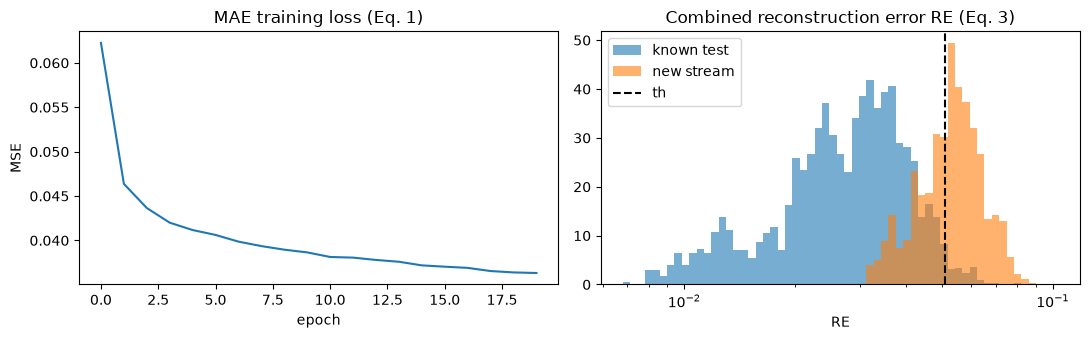

In [4]:
class MultiHeadAE(nn.Module):
    def __init__(self, d, k, dropout=0.5):
        super().__init__()
        self.drop_in = nn.Dropout(dropout)
        self.enc1 = nn.Linear(d, 64)
        self.drop_mid = nn.Dropout(dropout)
        self.enc2 = nn.Linear(64, 48)
        self.decoders = nn.ModuleList(
            [nn.Sequential(nn.Linear(48, 64), nn.ReLU(), nn.Linear(64, d)) for _ in range(k)])

    def encode(self, x):
        return F.relu(self.enc2(self.drop_mid(F.relu(self.enc1(self.drop_in(x))))))

    def forward(self, x):                       # -> (batch, k, d)
        z = self.encode(x)
        return torch.stack([dec(z) for dec in self.decoders], dim=1)


def train_mae(mae, X, y, cfg):
    # L2 regularisation only on the first dense encoder layer, as in Sec. 4.2.
    opt = torch.optim.Adam([
        {"params": mae.enc1.parameters(), "weight_decay": cfg["mae_l2"]},
        {"params": [p for n, p in mae.named_parameters() if not n.startswith("enc1")]},
    ], lr=cfg["mae_lr"])
    Xt, yt = torch.from_numpy(X), torch.from_numpy(y.astype(np.int64))
    hist = []
    for ep in range(cfg["mae_epochs"]):
        mae.train()
        perm, tot = torch.randperm(len(Xt)), 0.0
        for i in range(0, len(Xt), cfg["mae_batch"]):
            b = perm[i:i + cfg["mae_batch"]]
            out = mae(Xt[b])                                   # (B, k, d)
            own = out[torch.arange(len(b)), yt[b]]             # decoder of the sample's class
            loss = F.mse_loss(own, Xt[b])                      # Eq. 1
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(b)
        hist.append(tot / len(Xt))
    return hist


@torch.no_grad()
def reconstruction_error(mae, X):
    mae.eval()
    Xt = torch.from_numpy(X)
    per_head = ((mae(Xt) - Xt[:, None, :]) ** 2).mean(-1)      # Eq. 2, (N, k)
    return per_head.mean(1).numpy()                            # Eq. 3


@torch.no_grad()
def encode(mae, X):
    mae.eval()
    return mae.encode(torch.from_numpy(X)).numpy()


set_seed(CFG["seed"])
mae = MultiHeadAE(D, K, CFG["mae_dropout"])
t0 = time.time()
mae_hist = train_mae(mae, Xk_tr, yk_tr, CFG)
print(f"MAE training took {time.time() - t0:.1f}s, final loss {mae_hist[-1]:.5f}")

re_val = reconstruction_error(mae, Xk_val)
TH = float(np.quantile(re_val, CFG["mae_threshold_quantile"]))
re_stream = reconstruction_error(mae, Xn_stream)
re_kte = reconstruction_error(mae, Xk_te)
flag_stream = re_stream >= TH
print(f"threshold th = {TH:.5f} ({CFG['mae_threshold_quantile']:.0%} quantile of known-val RE)")
print(f"flagged as emerging: new stream {flag_stream.mean():.1%}  |  known test (false alarms) "
      f"{(re_kte >= TH).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(mae_hist); ax[0].set(title="MAE training loss (Eq. 1)", xlabel="epoch", ylabel="MSE")
bins = np.logspace(np.log10(max(1e-6, min(re_val.min(), re_stream.min()))),
                   np.log10(max(re_val.max(), re_stream.max())), 60)
ax[1].hist(re_kte, bins=bins, alpha=.6, label="known test", density=True)
ax[1].hist(re_stream, bins=bins, alpha=.6, label="new stream", density=True)
ax[1].axvline(TH, color="k", ls="--", label="th"); ax[1].set_xscale("log")
ax[1].set(title="Combined reconstruction error RE (Eq. 3)", xlabel="RE"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Layer 1b: DBSCAN semi-supervised labelling (Sec. 3.1.2, Alg. 2)

1. Encode the flagged samples (`m_new = f_θ(x_new)`) and a labelled subset of known traffic (`m`).
2. Run DBSCAN (`eps = 0.9`, `min_samples = 5`) on `m_combined = [m_new; m]`.
3. Give each cluster the most frequent known label among its labelled members. If a cluster holds
   no labelled member, use the majority label of the nearest labelled neighbours (Sec. 3.1.2).
4. Discard DBSCAN noise points (as in Sec. 4.3).

Ground-truth labels of the stream are used **only** to report the pseudo-label quality below.

Layer-1 labelling took 0.8s: 177 clusters, 0.6% of flagged samples are DBSCAN noise
pseudo-label accuracy on kept samples: 0.8254
pseudo     A     S    SS
true                    
A       3565   256   297
S        648  4608   406
SS       506   218  2844


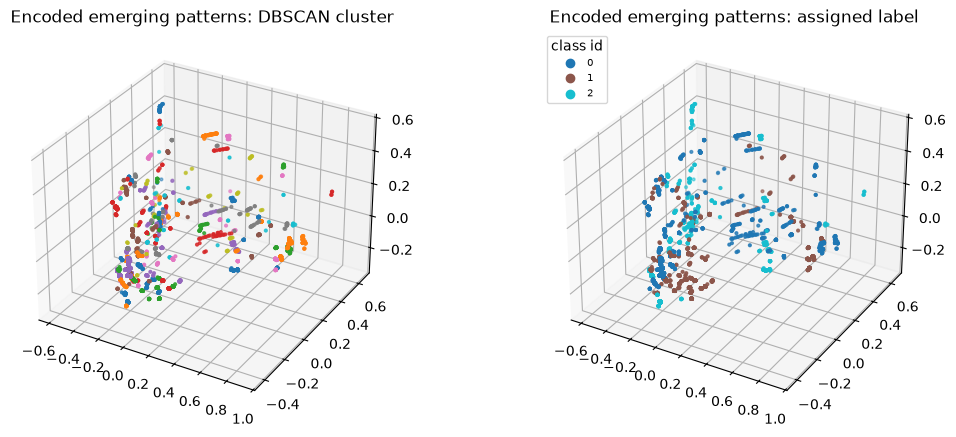

In [5]:
def label_new_patterns(mae, X_new, X_lab, y_lab, cfg):
    m_new, m_lab = encode(mae, X_new), encode(mae, X_lab)
    m_comb = np.vstack([m_new, m_lab])
    cl = DBSCAN(eps=cfg["dbscan_eps"], min_samples=cfg["dbscan_min_samples"],
                n_jobs=-1).fit_predict(m_comb)
    cl_new, cl_lab = cl[:len(m_new)], cl[len(m_new):]
    knn = KNeighborsClassifier(n_neighbors=cfg["knn_k"]).fit(m_lab, y_lab)
    y_new = np.full(len(m_new), -1)
    for c in np.unique(cl_new):
        if c == -1:
            continue                                          # noise -> dropped
        sel = cl_new == c
        known_in_cluster = y_lab[cl_lab == c]
        if len(known_in_cluster):
            y_new[sel] = np.bincount(known_in_cluster, minlength=K).argmax()
        else:
            y_new[sel] = np.bincount(knn.predict(m_new[sel]), minlength=K).argmax()
    return y_new, cl_new, m_new


# Labelled reference set: a class-balanced subset of known training traffic.
lab_idx = np.concatenate([rng.choice(np.where(yk_tr == c)[0],
                                     min(CFG["labeled_per_class"], (yk_tr == c).sum()),
                                     replace=False) for c in range(K)])
X_lab, y_lab = Xk_tr[lab_idx], yk_tr[lab_idx]

X_flag, y_flag_true = Xn_stream[flag_stream], yn_stream_true[flag_stream]
t0 = time.time()
y_pseudo, clusters, m_flag = label_new_patterns(mae, X_flag, X_lab, y_lab, CFG)
t_l1 = time.time() - t0
kept = y_pseudo >= 0
n_clusters = len(set(clusters[kept]))
print(f"Layer-1 labelling took {t_l1:.1f}s: {n_clusters} clusters, "
      f"{(~kept).mean():.1%} of flagged samples are DBSCAN noise")
print(f"pseudo-label accuracy on kept samples: {accuracy_score(y_flag_true[kept], y_pseudo[kept]):.4f}")
print(pd.crosstab(pd.Series(y_flag_true[kept], name="true").map(dict(enumerate(CLASS_NAMES))),
                  pd.Series(y_pseudo[kept], name="pseudo").map(dict(enumerate(CLASS_NAMES)))))

# Emerging-pattern pool that Layer 2 works with (pseudo-labelled; no ground truth).
X_newpat, y_newpat = X_flag[kept], y_pseudo[kept]

# Fig. 3: 3-D PCA of the clustered encodings.
pca = PCA(3, random_state=CFG["seed"]).fit(m_flag[kept])
P = pca.transform(m_flag[kept])
sub = rng.choice(len(P), min(4000, len(P)), replace=False)
fig = plt.figure(figsize=(11, 4.5))
for j, (col, title) in enumerate([(clusters[kept][sub], "DBSCAN cluster"),
                                  (y_newpat[sub], "assigned label")]):
    a = fig.add_subplot(1, 2, j + 1, projection="3d")
    sc = a.scatter(P[sub, 0], P[sub, 1], P[sub, 2], c=col, s=4, cmap="tab10")
    a.set_title(f"Encoded emerging patterns: {title}")
    if j == 1:
        a.legend(*sc.legend_elements(), title="class id", loc="upper left", fontsize=7)
plt.tight_layout(); plt.show()

## 6. Joint decision of MAE and classifier (Sec. 3.2.4)

* classifier says malicious, MAE says normal → **malicious**
* MAE flags the sample, classifier says benign → **malicious** (and the sample goes to clustering)

With more than one attack class, the second rule needs a choice of attack class. We use the most
probable non-benign class from the classifier.

In [6]:
def fused_predict(model, mae, X, th=None):
    th = TH if th is None else th
    p = predict_proba(model, X)
    pred = p.argmax(1)
    flagged = reconstruction_error(mae, X) >= th
    override = flagged & (pred == BENIGN_ID)
    p_att = p.copy(); p_att[:, BENIGN_ID] = -1
    pred[override] = p_att[override].argmax(1)
    return pred

for split, X, y in [("known/test", Xk_te, yk_te), ("new/test", Xn_te, yn_te)]:
    print(f"{split:11s} classifier alone acc={accuracy_score(y, predict_proba(base_clf, X).argmax(1)):.4f}"
          f" | fused with MAE acc={accuracy_score(y, fused_predict(base_clf, mae, X)):.4f}")

known/test  classifier alone acc=0.9667 | fused with MAE acc=0.9535
new/test    classifier alone acc=0.8290 | fused with MAE acc=0.6147


## 7. Layer 2a: memory (replay) buffer (Sec. 3.2.2)

The buffer is a two-dimensional queue: one fixed-size FIFO row per traffic class, holding no
duplicates. It is seeded with randomly sampled known traffic. During adaptation, emerging-pattern
samples that the classifier now predicts with high confidence, and in agreement with their Layer-1
label, are admitted to the buffer. This is the "pattern has been learned" condition of Sec. 3.2.2.
The oldest samples are evicted first.

In [7]:
class ReplayBuffer:
    def __init__(self, k, cap, seed=0):
        self.k, self.cap = k, cap
        self.rows = [deque(maxlen=cap) for _ in range(k)]
        self.keys = [deque(maxlen=cap) for _ in range(k)]
        self.rng = np.random.default_rng(seed)

    def add(self, X, y):
        added = 0
        for x, c in zip(X, y):
            key = x.tobytes()
            if key in self.keys[c]:
                continue                          # no duplicates
            self.rows[c].append(x.copy()); self.keys[c].append(key)
            added += 1
        return added

    def sample(self, c, n):
        n = min(int(n), len(self.rows[c]))
        if n <= 0:
            return np.empty((0, D), np.float32)
        idx = self.rng.choice(len(self.rows[c]), n, replace=False)
        return np.stack([self.rows[c][i] for i in idx])

    def counts(self):
        return np.array([len(r) for r in self.rows])

    def clone(self):
        return copy.deepcopy(self)


buffer0 = ReplayBuffer(K, CFG["buffer_cap"], CFG["seed"])
for c in range(K):
    idx = np.where(yk_tr == c)[0]
    buffer0.add(Xk_tr[rng.choice(idx, min(CFG["buffer_cap"], len(idx)), replace=False)],
                np.full(min(CFG["buffer_cap"], len(idx)), c))
print("buffer per class:", dict(zip(CLASS_NAMES, buffer0.counts())))

buffer per class: {'A': np.int64(1974), 'S': np.int64(1984), 'SS': np.int64(1959)}


## 8. Layer 2b: Conditional GAN (Sec. 3.2.1, 4.2) and its diagnostics (Sec. 4.3.1)

* **Generator**: `[z ∈ R^100, one-hot(label)]` → 3 × (Dense(128) → BatchNorm → SPOCU) → linear
  output. Adam, lr = 2e-4.
* **Discriminator**: `[x, one-hot(label)]` → Dense 256 / 128 / 64, each with LeakyReLU(0.2) and
  Dropout(0.3) → sigmoid. Adam, lr = 2e-4.
* **SPOCU** (Kiseľák et al.): `s(x) = α·h(x/γ + β) − α·h(β)` with `h(x) = r(min(x, c))` for x ≥ 0,
  otherwise 0, `r(x) = x³(x⁵ − 2x⁴ + 2)`, α = 3.0937, β = 0.6653, γ = 4.437, c = 327.6295.

The CGAN is pretrained on known traffic. It is then fine-tuned on the Layer-1 emerging patterns
mixed with real buffer traffic ("combined with real traffic flow", Sec. 3.2.1), using the lighter
early-stopped setting of Table 2 (4 epochs). Generated features are clamped to [0, 1].

CGAN pretraining 33.0s, fine-tuning on emerging patterns 4.2s


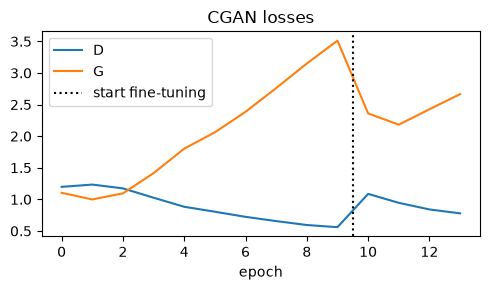

In [8]:
class SPOCU(nn.Module):
    def __init__(self, alpha=3.0937, beta=0.6653, gamma=4.437, c=327.6295):
        super().__init__()
        self.a, self.b, self.g, self.c = alpha, beta, gamma, c

    def _h(self, x):
        x = torch.clamp(x, 0.0, self.c)
        return x ** 3 * (x ** 5 - 2 * x ** 4 + 2)

    def forward(self, x):
        return self.a * self._h(x / self.g + self.b) - self.a * self._h(torch.tensor(self.b))


class Generator(nn.Module):
    def __init__(self, noise, k, d, hidden):
        super().__init__()
        layers, prev = [], noise + k
        for _ in range(3):
            layers += [nn.Linear(prev, hidden), nn.BatchNorm1d(hidden), SPOCU()]
            prev = hidden
        layers.append(nn.Linear(prev, d))
        self.net = nn.Sequential(*layers)

    def forward(self, z, y_onehot):
        return self.net(torch.cat([z, y_onehot], 1))


class Discriminator(nn.Module):
    def __init__(self, k, d):
        super().__init__()
        layers, prev = [], d + k
        for h in (256, 128, 64):
            layers += [nn.Linear(prev, h), nn.LeakyReLU(0.2), nn.Dropout(0.3)]
            prev = h
        layers.append(nn.Linear(prev, 1))          # sigmoid is inside BCEWithLogitsLoss
        self.net = nn.Sequential(*layers)

    def forward(self, x, y_onehot):
        return self.net(torch.cat([x, y_onehot], 1))


class CGAN:
    def __init__(self, k, d, cfg):
        self.k, self.noise = k, cfg["gan_noise"]
        self.G = Generator(cfg["gan_noise"], k, d, cfg["gan_hidden"])
        self.D = Discriminator(k, d)
        self.opt_g = torch.optim.Adam(self.G.parameters(), lr=cfg["gan_lr"], betas=(0.5, 0.999))
        self.opt_d = torch.optim.Adam(self.D.parameters(), lr=cfg["gan_lr"], betas=(0.5, 0.999))
        self.batch = cfg["gan_batch"]
        self.history = []

    def fit(self, X, y, epochs):
        # Class-balanced sampling so that rare classes are not ignored by the generator.
        w = 1.0 / np.bincount(y, minlength=self.k)[y]
        w = torch.from_numpy(w / w.sum())
        Xt, yt = torch.from_numpy(X), torch.from_numpy(y.astype(np.int64))
        n_batches = max(1, len(X) // self.batch)
        for _ in range(epochs):
            self.G.train(); self.D.train()
            ld = lg = 0.0
            for _ in range(n_batches):
                b = torch.multinomial(w, self.batch, replacement=True)
                xr, yo = Xt[b], F.one_hot(yt[b], self.k).float()
                xf = self.G(torch.randn(len(b), self.noise), yo)
                # discriminator: real -> 0.9 (label smoothing), fake -> 0
                d_loss = (F.binary_cross_entropy_with_logits(self.D(xr, yo), torch.full((len(b), 1), 0.9))
                          + F.binary_cross_entropy_with_logits(self.D(xf.detach(), yo), torch.zeros(len(b), 1)))
                self.opt_d.zero_grad(); d_loss.backward(); self.opt_d.step()
                g_loss = F.binary_cross_entropy_with_logits(self.D(xf, yo), torch.ones(len(b), 1))
                self.opt_g.zero_grad(); g_loss.backward(); self.opt_g.step()
                ld += d_loss.item(); lg += g_loss.item()
            self.history.append((ld / n_batches, lg / n_batches))

    @torch.no_grad()
    def generate(self, c, n):
        if n <= 0:
            return np.empty((0, D), np.float32)
        self.G.eval()
        yo = F.one_hot(torch.full((int(n),), int(c)), self.k).float()
        X = self.G(torch.randn(int(n), self.noise), yo).clamp(0, 1).numpy()
        for g in ONEHOT_GROUPS:                  # snap each one-hot group to a valid category
            hot = X[:, g].argmax(1)
            X[:, g] = 0.0
            X[np.arange(len(X)), np.asarray(g)[hot]] = 1.0
        return X


set_seed(CFG["seed"])
cgan_base = CGAN(K, D, CFG)
t0 = time.time()
cgan_base.fit(Xk_tr, yk_tr, CFG["gan_pretrain_epochs"])
t_gan_pre = time.time() - t0


def finetune_cgan(X_np, y_np, seed=CFG["seed"]):
    """Copy of the pretrained CGAN fine-tuned on emerging patterns + real buffer traffic."""
    set_seed(seed)
    r = np.random.default_rng(seed)
    cg = copy.deepcopy(cgan_base)
    mix_c = r.integers(0, K, int(CFG["gan_real_mix"] * len(X_np)))
    real_parts = [buffer0.sample(c, (mix_c == c).sum()) for c in range(K)]
    X_mix = np.vstack([X_np] + real_parts).astype(np.float32)
    y_mix = np.concatenate([y_np] + [np.full(len(p), c) for c, p in enumerate(real_parts)])
    t0 = time.time()
    cg.fit(X_mix, y_mix, CFG["gan_finetune_epochs"])
    return cg, time.time() - t0


cgan, t_gan_ft = finetune_cgan(X_newpat, y_newpat)
print(f"CGAN pretraining {t_gan_pre:.1f}s, fine-tuning on emerging patterns {t_gan_ft:.1f}s")

h = np.array(cgan.history)
plt.figure(figsize=(5, 3)); plt.plot(h[:, 0], label="D"); plt.plot(h[:, 1], label="G")
plt.axvline(CFG["gan_pretrain_epochs"] - .5, color="k", ls=":", label="start fine-tuning")
plt.title("CGAN losses"); plt.xlabel("epoch"); plt.legend(); plt.tight_layout(); plt.show()

CGAN diagnostics on the Layer-1 emerging patterns (Table 2)


target class,A,S,SS
real samples,4719.0000,5082.0000,3547.0000
diversity ratio,1.0187,1.0006,0.9947
feature mean abs. diff,0.0676,0.0533,0.0698
feature std abs. diff,0.0897,0.0724,0.0890
generated-to-real NN distance,1.2948,1.4528,1.3836
CGAN fine-tuning time (s),4.1896,4.1896,4.1896
generation time for 2000 samples (s),0.0095,0.0056,0.0055


TSTR accuracy on known/test: 0.6865 (real-data classifier: 0.9667)


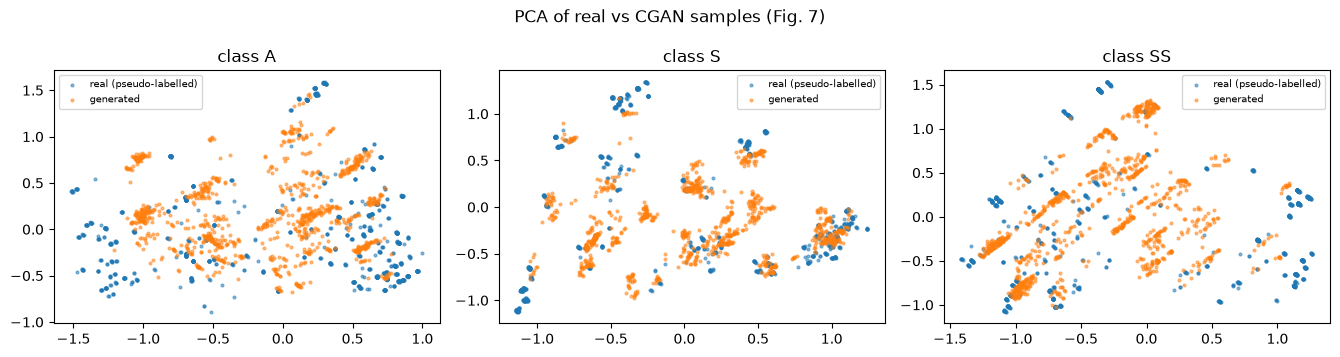

In [9]:
def cgan_diagnostics(cgan, X_real, c, n_gen=2000, n_pairs=5000, seed=0):
    """Sec. 4.3.1 / Table 2: diversity ratio, feature-statistics match, NN distance, timing."""
    r = np.random.default_rng(seed)
    t0 = time.time(); Xg = cgan.generate(c, n_gen); t_gen = time.time() - t0

    def mean_pairwise(X):
        i, j = r.integers(0, len(X), n_pairs), r.integers(0, len(X), n_pairs)
        return np.linalg.norm(X[i] - X[j], axis=1).mean()

    nn_d = NearestNeighbors(n_neighbors=1).fit(X_real).kneighbors(Xg)[0].mean()
    return {"target class": CLASS_NAMES[c], "real samples": len(X_real),
            "diversity ratio": mean_pairwise(Xg) / max(mean_pairwise(X_real), 1e-12),
            "feature mean abs. diff": np.abs(Xg.mean(0) - X_real.mean(0)).mean(),
            "feature std abs. diff": np.abs(Xg.std(0) - X_real.std(0)).mean(),
            "generated-to-real NN distance": nn_d,
            "CGAN fine-tuning time (s)": t_gan_ft,
            f"generation time for {n_gen} samples (s)": t_gen}, Xg


diag_rows, diag_gen = [], {}
for c in range(K):
    real_c = X_newpat[y_newpat == c]
    if len(real_c) < 10:
        continue
    row, Xg = cgan_diagnostics(cgan, real_c, c, seed=CFG["seed"])
    diag_rows.append(row); diag_gen[c] = (real_c, Xg)
display_df = pd.DataFrame(diag_rows).set_index("target class").T
print("CGAN diagnostics on the Layer-1 emerging patterns (Table 2)")
display(display_df.round(4))

# Extra diagnostic (not in the paper): "train on synthetic, test on real". A classifier trained only
# on CGAN samples is evaluated on real known traffic. This checks whether the class-conditional
# structure that matters for fine-tuning is captured, beyond the distribution statistics above.
G_syn = np.vstack([cgan.generate(c, 5000) for c in range(K)]); y_syn = np.repeat(np.arange(K), 5000)
set_seed(CFG["seed"])
m_syn = NIDClassifier(D, K, CFG["clf_hidden"])
train_classifier(m_syn, G_syn, y_syn, 5, CFG["clf_lr"], CFG["clf_batch"])
print(f"TSTR accuracy on known/test: {accuracy_score(yk_te, predict_proba(m_syn, Xk_te).argmax(1)):.4f} "
      f"(real-data classifier: {accuracy_score(yk_te, predict_proba(base_clf, Xk_te).argmax(1)):.4f})")

# Fig. 7: PCA of real vs generated target-class samples.
fig, axes = plt.subplots(1, len(diag_gen), figsize=(4.5 * len(diag_gen), 3.6), squeeze=False)
for a, (c, (real_c, Xg)) in zip(axes[0], diag_gen.items()):
    p = PCA(2).fit(real_c)
    rs = real_c[rng.choice(len(real_c), min(1000, len(real_c)), replace=False)]
    a.scatter(*p.transform(rs).T, s=4, alpha=.5, label="real (pseudo-labelled)")
    a.scatter(*p.transform(Xg[:1000]).T, s=4, alpha=.5, label="generated")
    a.set_title(f"class {CLASS_NAMES[c]}"); a.legend(fontsize=7)
plt.suptitle("PCA of real vs CGAN samples (Fig. 7)"); plt.tight_layout(); plt.show()

## 9. Layer 2c: MDP environment for autonomous continual learning (Sec. 3.2.3)

**State (Eq. 5)**: `S = [S_B, S_P, S_N, N_A^min, N_A^max]`
* `S_B`: buffer occupancy per class (normalised by capacity)
* `S_P`: accuracy, macro-F1 and the row-normalised confusion matrix of the classifier on the data
  clustered by Layer 1 (pseudo-labelled emerging patterns + known validation traffic)
* `S_N`: number of new patterns detected, initial and current accuracy on them
* `N_A^min, N_A^max` normalised by their upper bound

**Action (Eq. 4)**: `A = [A_S, A_A]` ∈ [-1, 1]^(2+2k)
* `A_S = [ΔN_A^min, ΔN_A^max]` (each up to ±`n_delta`). `N_A^max` is capped by `n_max_cap`, which is
  at most the buffer capacity.
* `A_A`: for every class, one value for CGAN and one for the buffer. Each is mapped to a count in
  `[N_A^min, N_A^max]`. An all-zero allocation means *do not fine-tune this round*, which is how the
  agent decides **when** to adapt.

**Reward (Eqs. 6–8)**: `R = Σ_i λ_i ΔAcc_i − β Σ_i (N_CGAN,i + N_buf,i)(1 − ΔAcc_i)`, where `Acc_i`
is the per-class accuracy (recall) on the evaluation set and the counts are normalised by the
buffer capacity (the bound on `N_A^max` in Sec. 3.2.3). Following the authors' code, `λ` gives a 2 : 1 weight to attack classes
(`attack_priority`) or to benign (`benign_priority`) and is normalised to sum to 1.

An episode is `episode_len` fine-tuning rounds starting from the pretrained classifier.
Each round fine-tunes the classifier on the selected samples.

In [10]:
def lambda_vector(mode):
    w = np.ones(K)
    if mode == "attack_priority":
        w[[c for c in range(K) if c != BENIGN_ID]] = 2.0
    elif mode == "benign_priority":
        w[BENIGN_ID] = 2.0
    return w / w.sum()


def make_task(X_np, y_np, seed=CFG["seed"]):
    """Split the labelled emerging patterns into a pool (buffer admission) and the reward's eval set.

    The reward evaluation set = 1/3 of the emerging patterns (with the labels Layer 1 gave them)
    + known validation traffic.
    """
    r = np.random.default_rng(seed)
    idx = r.permutation(len(X_np))
    n_ev = len(idx) // 3
    kv = np.concatenate([r.choice(np.where(yk_val == c)[0],
                                  min(CFG["eval_known_per_class"], (yk_val == c).sum()),
                                  replace=False) for c in range(K)])
    X_eval = np.vstack([X_np[idx[:n_ev]], Xk_val[kv]])
    y_eval = np.concatenate([y_np[idx[:n_ev]], yk_val[kv]])
    new_mask = np.zeros(len(y_eval), bool); new_mask[:n_ev] = True
    return dict(X_pool=X_np[idx[n_ev:]], y_pool=y_np[idx[n_ev:]], X_eval=X_eval, y_eval=y_eval,
                new_mask=new_mask, n_new=len(X_np))


task_l1 = make_task(X_newpat, y_newpat)
print(f"reward evaluation set: {task_l1['new_mask'].sum()} emerging (Layer-1 labels) + "
      f"{(~task_l1['new_mask']).sum()} known")


class GardianEnv(gym.Env):
    """mode: 'hybrid' (CGAN + buffer, GARDIAN), 'cgan' (CGAN only), 'buffer' (buffer only)."""

    def __init__(self, base_model, cgan, buffer, task, cfg, mode="hybrid",
                 beta=None, lam_mode=None, seed=0):
        super().__init__()
        self.task = task
        self.base_state = copy.deepcopy(base_model.state_dict())
        self.model = copy.deepcopy(base_model)
        self.cgan, self.buffer0, self.cfg, self.mode = cgan, buffer, cfg, mode
        self.beta = cfg["reward_beta"] if beta is None else beta
        self.lam = lambda_vector(cfg["reward_lambda"] if lam_mode is None else lam_mode)
        self.rng = np.random.default_rng(seed)
        self.T, self.cap, self.dn = cfg["episode_len"], cfg["n_max_cap"], cfg["n_delta"]
        self.action_space = spaces.Box(-1.0, 1.0, shape=(2 + 2 * K,), dtype=np.float32)
        obs_dim = K + (2 + K * K) + 3 + 2
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(obs_dim,), dtype=np.float32)

    # -- helpers -----------------------------------------------------------------
    def _evaluate(self):
        t = self.task
        pred = predict_proba(self.model, t["X_eval"]).argmax(1)
        m = metrics(t["y_eval"], pred)
        m["acc_new"] = accuracy_score(t["y_eval"][t["new_mask"]], pred[t["new_mask"]])
        return m

    def _obs(self):
        m = self.m
        cm = m["cm"] / np.maximum(m["cm"].sum(1, keepdims=True), 1)
        return np.concatenate([
            self.buffer.counts() / self.buffer.cap,                         # S_B
            [m["acc"], m["f1"]], cm.ravel(),                                # S_P
            [self.task["n_new"] / self.cfg["unseen_cap"], self.acc_new0, m["acc_new"]],  # S_N
            [self.n_min / self.cap, self.n_max / self.cap],                 # N_A^min, N_A^max
        ]).astype(np.float32)

    def decode(self, a):
        a = np.clip(np.asarray(a, dtype=np.float64), -1, 1)
        self.n_min = int(np.clip(self.n_min + round(a[0] * self.dn), 0, self.cap))
        self.n_max = int(np.clip(self.n_max + round(a[1] * self.dn), self.n_min, self.cap))
        frac = (a[2:].reshape(K, 2) + 1) / 2                                 # [cgan, buffer] per class
        counts = np.rint(self.n_min + frac * (self.n_max - self.n_min)).astype(int)
        if self.mode == "cgan":
            counts[:, 1] = 0
        elif self.mode == "buffer":
            counts[:, 0] = 0
        return counts

    def _admit_learned_patterns(self):
        # Sec. 3.2.2: emerging samples the classifier now handles confidently enter the buffer.
        Xp, yp = self.task["X_pool"], self.task["y_pool"]
        p = predict_proba(self.model, Xp)
        ok = (p.max(1) >= self.cfg["buffer_admit_conf"]) & (p.argmax(1) == yp)
        for c in range(K):
            idx = np.where(ok & (yp == c))[0]
            if len(idx):
                idx = self.rng.choice(idx, min(len(idx), self.cfg["buffer_admit_per_round"]), replace=False)
                self.buffer.add(Xp[idx], yp[idx])

    # -- gym API -----------------------------------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.model.load_state_dict(self.base_state)
        self.opt = torch.optim.Adam(self.model.parameters(), lr=self.cfg["finetune_lr"])
        self.buffer = self.buffer0.clone()
        self.n_min, self.n_max = self.cfg["n_init"]
        self.t, self.ep_return = 0, 0.0
        self.m = self._evaluate()
        self.acc_new0 = self.m["acc_new"]
        return self._obs(), {}

    def step(self, action):
        counts = self.decode(action)
        Xs_, ys_ = [], []
        for c in range(K):
            Xs_.append(self.cgan.generate(c, counts[c, 0])); ys_.append(np.full(len(Xs_[-1]), c))
            Xs_.append(self.buffer.sample(c, counts[c, 1])); ys_.append(np.full(len(Xs_[-1]), c))
        Xft, yft = np.vstack(Xs_).astype(np.float32), np.concatenate(ys_)
        n_cgan = sum(len(Xs_[2 * c]) for c in range(K))
        n_buf = len(yft) - n_cgan

        before = self.m
        t0 = time.time()
        if len(yft):
            train_classifier(self.model, Xft, yft, self.cfg["finetune_epochs"], None,
                             self.cfg["finetune_batch"], opt=self.opt)
            self._admit_learned_patterns()
        t_round = time.time() - t0
        self.m = self._evaluate()

        d_acc = self.m["recall"] - before["recall"]                                    # ΔAcc_i
        r_p = float(np.sum(self.lam * d_acc))                                          # Eq. 6
        used = np.array([len(Xs_[2 * c]) + len(Xs_[2 * c + 1]) for c in range(K)]) / self.buffer.cap
        r_e = float(-self.beta * np.sum(used * (1 - d_acc)))                           # Eq. 7
        reward = r_p + r_e                                                             # Eq. 8
        self.t += 1
        self.ep_return += reward
        info = dict(round=self.t, n_total=len(yft), n_cgan=n_cgan, n_buffer=n_buf,
                    n_min=self.n_min, n_max=self.n_max, r_p=r_p, r_e=r_e, reward=reward,
                    acc=self.m["acc"], f1=self.m["f1"], acc_new=self.m["acc_new"],
                    d_f1=self.m["f1"] - before["f1"], t_round=t_round,
                    triggered=len(yft) > 0, buffer=self.buffer.counts().tolist(),
                    episode_return=self.ep_return)
        return self._obs(), reward, False, self.t >= self.T, info


env_check = GardianEnv(base_clf, cgan, buffer0, task_l1, CFG)
o, _ = env_check.reset()
o2, r, *_ , info = env_check.step(env_check.action_space.sample())
print("obs dim", o.shape, "| random-action round:",
      {k: (round(v, 4) if isinstance(v, float) else v) for k, v in info.items()})

reward evaluation set: 4449 emerging (Layer-1 labels) + 3000 known
obs dim (19,) | random-action round: {'round': 1, 'n_total': 308, 'n_cgan': 114, 'n_buffer': 194, 'n_min': 0, 'n_max': 115, 'r_p': 0.0024, 'r_e': -0.0008, 'reward': 0.0016, 'acc': 0.8542, 'f1': 0.8552, 'acc_new': 0.8078, 'd_f1': -0.0236, 't_round': 0.0177, 'triggered': True, 'buffer': [2000, 2000, 2000], 'episode_return': 0.0016}


## 10. PPO agent (Alg. 3)

We use Stable-Baselines3 PPO with the paper's settings: γ = 0.99, clip ratio 0.2, lr = 3e-4.
SB3 uses a single learning rate, so the critic does not get its own 1e-3. GAE (λ = 0.95) and the
clipped surrogate objective are as in Alg. 3. Two stabilisers are added: reward normalisation
and a smaller initial policy standard deviation (`log_std_init = -1`). The callback records the return of every episode
(Fig. 4a) and the classifier accuracy at the end of the episode (Fig. 4b).

[hybrid] PPO training: 300 episodes in 80s, last-10 mean return 0.0043


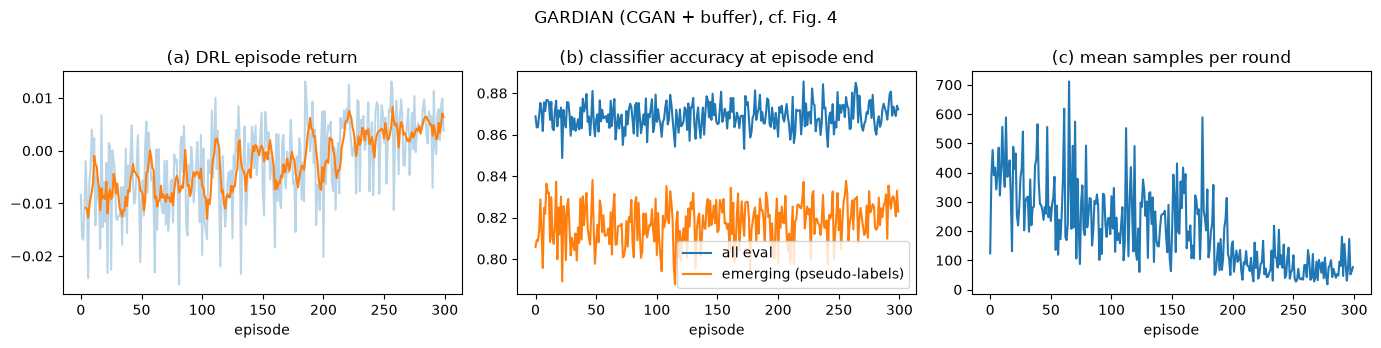

In [11]:
class EpisodeLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.returns, self.acc, self.acc_new, self.samples, self.n_round = [], [], [], [], []

    def _on_step(self):
        for info, done in zip(self.locals["infos"], self.locals["dones"]):
            self.n_round.append(info["n_total"])
            if done:                          # the VecEnv has already reset; read the info dict
                self.returns.append(info["episode_return"])
                self.acc.append(info["acc"]); self.acc_new.append(info["acc_new"])
                self.samples.append(np.mean(self.n_round[-CFG["episode_len"]:]))
        return True


def train_ppo(mode="hybrid", task=None, gan=None, timesteps=None, beta=None, lam_mode=None,
              seed=None, verbose=True, tag=""):
    seed = CFG["seed"] if seed is None else seed
    set_seed(seed)
    env = GardianEnv(base_clf, gan or cgan, buffer0, task or task_l1, CFG, mode=mode,
                     beta=beta, lam_mode=lam_mode, seed=seed)
    # Per-round rewards are small (~1e-2) and noisy, so returns are normalised (VecNormalize) and the
    # initial exploration noise is reduced; without this PPO did not converge in our runs.
    venv = VecNormalize(DummyVecEnv([lambda: env]), norm_obs=False, norm_reward=True,
                        gamma=CFG["ppo_gamma"])
    agent = PPO("MlpPolicy", venv, n_steps=CFG["ppo_n_steps"], batch_size=CFG["ppo_batch"],
                n_epochs=CFG["ppo_epochs"], learning_rate=CFG["ppo_lr"], gamma=CFG["ppo_gamma"],
                gae_lambda=0.95, clip_range=CFG["ppo_clip"], seed=seed, verbose=0, device="cpu",
                policy_kwargs=dict(log_std_init=CFG["ppo_log_std_init"]))
    cb = EpisodeLogger()
    t0 = time.time()
    agent.learn(total_timesteps=timesteps or CFG["ppo_timesteps"], callback=cb)
    if verbose:
        print(f"[{tag or mode}] PPO training: {len(cb.returns)} episodes in {time.time() - t0:.0f}s, "
              f"last-10 mean return {np.mean(cb.returns[-10:]):.4f}")
    return agent, env, cb, time.time() - t0


agent, env, cb, t_ppo = train_ppo("hybrid")

def smooth(x, w=5):
    x = np.asarray(x, float)
    return np.convolve(x, np.ones(w) / w, mode="valid") if len(x) >= w else x

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
ax[0].plot(cb.returns, alpha=.3); ax[0].plot(range(4, 4 + len(smooth(cb.returns))), smooth(cb.returns))
ax[0].set(title="(a) DRL episode return", xlabel="episode")
ax[1].plot(cb.acc, label="all eval"); ax[1].plot(cb.acc_new, label="emerging (pseudo-labels)")
ax[1].set(title="(b) classifier accuracy at episode end", xlabel="episode"); ax[1].legend()
ax[2].plot(cb.samples); ax[2].set(title="(c) mean samples per round", xlabel="episode")
plt.suptitle("GARDIAN (CGAN + buffer), cf. Fig. 4"); plt.tight_layout(); plt.show()

## 11. Autonomous adaptation with the trained policy and RL diagnostics (Sec. 4.3.2, Table 3, Fig. 8)

The deployed policy runs one adaptation episode: it starts from the pretrained classifier and the
seeded buffer and makes `episode_len` decisions without human intervention.

Total PPO adaptation (training) time (s)    79.7443
Mean policy inference time (ms)              0.4963
Max policy inference time (ms)               0.6129
Mean retraining-round time (s)               0.0039
Number of policy decisions                  10.0000
Policy decisions without manual override    10.0000
Autonomy rate (Eq. 9)                        1.0000
Rounds where fine-tuning was triggered       4.0000
Mean total samples selected per round       47.8000
Mean CGAN samples selected per round        24.5000
Mean replay samples selected per round      23.3000
Final total samples selected                 0.0000
Final CGAN fraction                          0.0000
Mean post-update delta macro-F1             -0.0011
Best post-update delta macro-F1              0.0028
Std. total samples selected per round       84.6822


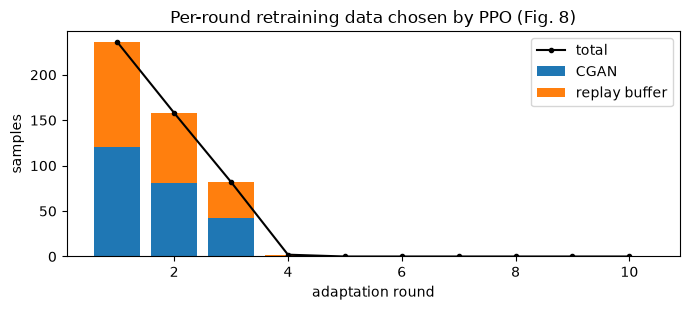

,round,n_min,n_max,n_cgan,n_buffer,reward,acc,acc_new,f1
0,1,0,76,121,115,0.0087,0.8813,0.8294,0.8816
1,2,0,51,81,77,-0.0061,0.8670,0.8148,0.8675
2,3,0,26,42,40,0.0030,0.8668,0.8186,0.8674
3,4,0,1,1,1,0.0007,0.8668,0.8197,0.8674
4,5,0,0,0,0,0.0000,0.8668,0.8197,0.8674
5,6,0,0,0,0,0.0000,0.8668,0.8197,0.8674
6,7,0,0,0,0,0.0000,0.8668,0.8197,0.8674
7,8,0,0,0,0,0.0000,0.8668,0.8197,0.8674
8,9,0,0,0,0,0.0000,0.8668,0.8197,0.8674
9,10,0,0,0,0,0.0000,0.8668,0.8197,0.8674


In [12]:
def deploy(agent, mode="hybrid", task=None, gan=None, seed=None, beta=None, lam_mode=None):
    seed = CFG["seed"] if seed is None else seed
    set_seed(seed)
    env = GardianEnv(base_clf, gan or cgan, buffer0, task or task_l1, CFG, mode=mode,
                     beta=beta, lam_mode=lam_mode, seed=seed)
    obs, _ = env.reset()
    rows, inf_t, done = [], [], False
    while not done:
        t0 = time.perf_counter()
        a, _ = agent.predict(obs, deterministic=True)
        inf_t.append((time.perf_counter() - t0) * 1000)
        obs, r, term, trunc, info = env.step(a)
        rows.append(info); done = term or trunc
    return env.model, pd.DataFrame(rows), np.array(inf_t)


final_clf, rounds, inf_ms = deploy(agent)
n_dec = len(rounds)
rl_diag = {
    "Total PPO adaptation (training) time (s)": t_ppo,
    "Mean policy inference time (ms)": inf_ms.mean(),
    "Max policy inference time (ms)": inf_ms.max(),
    "Mean retraining-round time (s)": rounds["t_round"].mean(),
    "Number of policy decisions": n_dec,
    "Policy decisions without manual override": n_dec,
    "Autonomy rate (Eq. 9)": 1.0,
    "Rounds where fine-tuning was triggered": int(rounds["triggered"].sum()),
    "Mean total samples selected per round": rounds["n_total"].mean(),
    "Mean CGAN samples selected per round": rounds["n_cgan"].mean(),
    "Mean replay samples selected per round": rounds["n_buffer"].mean(),
    "Final total samples selected": int(rounds["n_total"].iloc[-1]),
    "Final CGAN fraction": rounds["n_cgan"].iloc[-1] / max(1, rounds["n_total"].iloc[-1]),
    "Mean post-update delta macro-F1": rounds["d_f1"].mean(),
    "Best post-update delta macro-F1": rounds["d_f1"].max(),
    "Std. total samples selected per round": rounds["n_total"].std(),
}
print(pd.Series(rl_diag).round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(rounds["round"], rounds["n_cgan"], label="CGAN")
ax.bar(rounds["round"], rounds["n_buffer"], bottom=rounds["n_cgan"], label="replay buffer")
ax.plot(rounds["round"], rounds["n_total"], "k.-", label="total")
ax.set(xlabel="adaptation round", ylabel="samples", title="Per-round retraining data chosen by PPO (Fig. 8)")
ax.legend(); plt.tight_layout(); plt.show()
rounds[["round", "n_min", "n_max", "n_cgan", "n_buffer", "reward", "acc", "acc_new", "f1"]].round(4)

## 12. Results: before vs after autonomous adaptation (ground-truth labels)

Accuracy on **new/test** measures adaptation to the emerging patterns. Accuracy on **known/test**
measures catastrophic forgetting.

In [13]:
results.append(report(final_clf, "GARDIAN (CGAN + buffer)"))
pd.concat(results).round(4)

,model,split,accuracy,macro_f1,recall_A,recall_S,recall_SS
0,pretrained (no adaptation),known/test,0.9667,0.9660,0.9709,0.9585,0.9757
1,pretrained (no adaptation),new/test,0.8290,0.8251,0.7573,0.8352,0.9029
2,pretrained (no adaptation),all test,0.8680,0.8647,0.8135,0.8704,0.9247
0,GARDIAN (CGAN + buffer),known/test,0.9119,0.9137,0.9813,0.8280,0.9788
1,GARDIAN (CGAN + buffer),new/test,0.8187,0.8173,0.8313,0.7561,0.9118
2,GARDIAN (CGAN + buffer),all test,0.8451,0.8445,0.8708,0.7767,0.9319


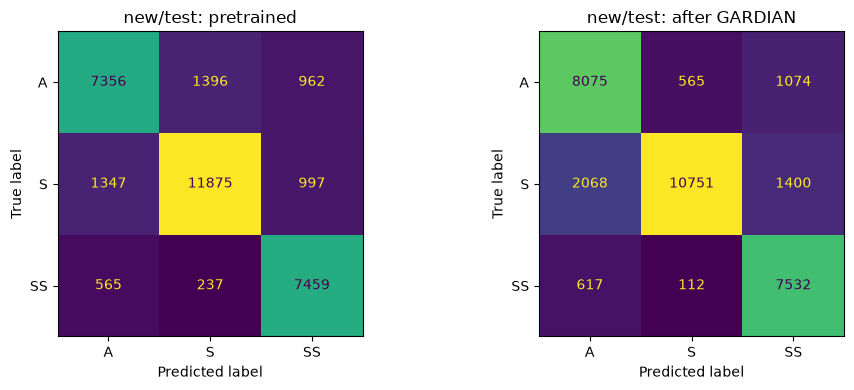

              precision    recall  f1-score   support

           A     0.7505    0.8313    0.7888      9714
           S     0.9408    0.7561    0.8384     14219
          SS     0.7527    0.9118    0.8247      8261

    accuracy                         0.8187     32194
   macro avg     0.8147    0.8330    0.8173     32194
weighted avg     0.8351    0.8187    0.8199     32194

fused MAE + classifier (Sec. 3.2.4), new/test accuracy: 0.6081


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (name, model) in zip(ax, [("pretrained", base_clf), ("after GARDIAN", final_clf)]):
    ConfusionMatrixDisplay(confusion_matrix(yn_te, predict_proba(model, Xn_te).argmax(1), labels=range(K)),
                           display_labels=CLASS_NAMES).plot(ax=a, colorbar=False, values_format="d")
    a.set_title(f"new/test: {name}")
plt.tight_layout(); plt.show()
print(classification_report(yn_te, predict_proba(final_clf, Xn_te).argmax(1),
                            target_names=CLASS_NAMES, digits=4))
print("fused MAE + classifier (Sec. 3.2.4), new/test accuracy:",
      round(accuracy_score(yn_te, fused_predict(final_clf, mae, Xn_te)), 4))

## 13. Ablation study (Sec. 4.3.4, Figs. 4–6)

* **Scenario 1**: GARDIAN, with DRL + CGAN + memory buffer
* **Scenario 2**: DRL + CGAN only (comparable to [11] in the paper)
* **Scenario 3**: DRL + memory buffer only (comparable to [34] in the paper)

[cgan] PPO training: 300 episodes in 72s, last-10 mean return 0.0041
   deployed: 2 fine-tuning rounds, 15.2 samples/round


[buffer] PPO training: 300 episodes in 76s, last-10 mean return -0.0014


   deployed: 10 fine-tuning rounds, 117.0 samples/round


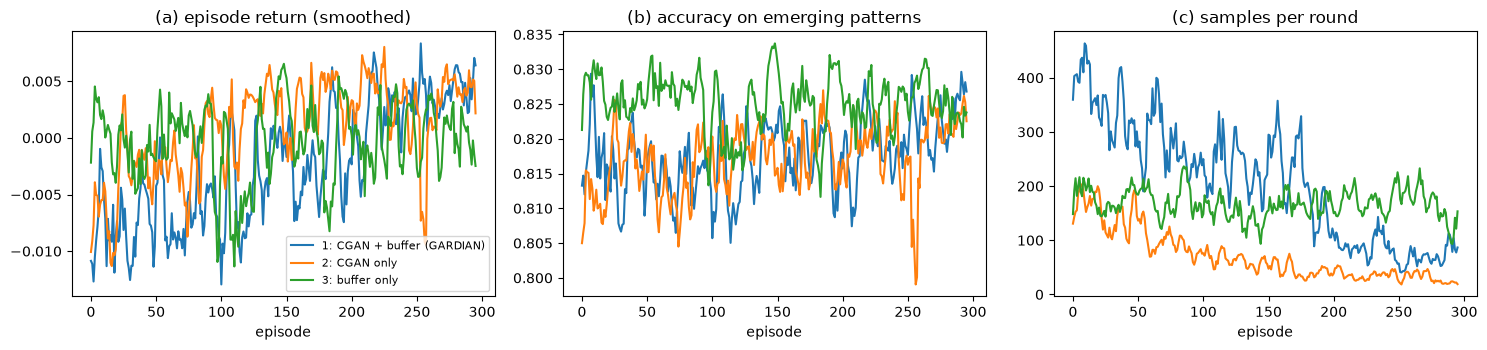

accuracy            macro_f1         
split                      known/test new/test known/test new/test
model                                                             
GARDIAN (CGAN + buffer)        0.9119   0.8187     0.9137   0.8173
pretrained (no adaptation)     0.9667   0.8290     0.9660   0.8251
scenario 2: CGAN only          0.9325   0.8266     0.9332   0.8249
scenario 3: buffer only        0.9585   0.8365     0.9564   0.8337

In [15]:
if CFG["run_ablation"]:
    curves = {"1: CGAN + buffer (GARDIAN)": cb}
    for mode, name in [("cgan", "2: CGAN only"), ("buffer", "3: buffer only")]:
        ag, _, cb_m, _ = train_ppo(mode)
        curves[name] = cb_m
        model_m, rounds_m, _ = deploy(ag, mode=mode)
        print(f"   deployed: {int(rounds_m.triggered.sum())} fine-tuning rounds, "
              f"{rounds_m.n_total.mean():.1f} samples/round")
        results.append(report(model_m, f"scenario {name}"))

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
    for name, c in curves.items():
        ax[0].plot(smooth(c.returns), label=name)
        ax[1].plot(smooth(c.acc_new), label=name)
        ax[2].plot(smooth(c.samples), label=name)
    ax[0].set(title="(a) episode return (smoothed)", xlabel="episode")
    ax[1].set(title="(b) accuracy on emerging patterns", xlabel="episode")
    ax[2].set(title="(c) samples per round", xlabel="episode")
    ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

table = pd.concat(results)
table[table.split != "all test"].pivot(index="model", columns="split",
                                       values=["accuracy", "macro_f1"]).round(4)

## 14. Where is the bottleneck? Layer 2 with administrator labels

Sec. 3.1.1 lets an administrator optionally label the flagged emerging patterns. Running Layer 2
unchanged on the same flagged samples, but with their true labels, separates two failure sources:

* if adaptation improves here, the PPO + CGAN + buffer loop works and **Layer-1 label quality** is
  what limits the autonomous run;
* if it does not, the limit is in Layer 2 itself (e.g. CGAN sample quality).

This run is **not autonomous**. It uses ground-truth labels and is a diagnostic only.

In [16]:
task_admin = make_task(X_flag, y_flag_true)
cgan_admin, _ = finetune_cgan(X_flag, y_flag_true)
for mode, name in [("hybrid", "admin labels: CGAN + buffer"), ("buffer", "admin labels: buffer only")]:
    ag, _, cb_a, _ = train_ppo(mode, task=task_admin, gan=cgan_admin, tag=name)
    model_a, rounds_a, _ = deploy(ag, mode=mode, task=task_admin, gan=cgan_admin)
    print(f"   deployed: {int(rounds_a.triggered.sum())} fine-tuning rounds, "
          f"{rounds_a.n_total.mean():.1f} samples/round "
          f"({rounds_a.n_cgan.mean():.1f} CGAN, {rounds_a.n_buffer.mean():.1f} buffer)")
    results.append(report(model_a, name))

table = pd.concat(results)
table[table.split != "all test"].pivot(index="model", columns="split",
                                       values=["accuracy", "macro_f1"]).round(4)

[admin labels: CGAN + buffer] PPO training: 300 episodes in 91s, last-10 mean return 0.0044


   deployed: 8 fine-tuning rounds, 103.6 samples/round (53.3 CGAN, 50.3 buffer)


[admin labels: buffer only] PPO training: 300 episodes in 80s, last-10 mean return 0.0006


   deployed: 10 fine-tuning rounds, 213.2 samples/round (0.0 CGAN, 213.2 buffer)


accuracy            macro_f1         
split                       known/test new/test known/test new/test
model                                                              
GARDIAN (CGAN + buffer)         0.9119   0.8187     0.9137   0.8173
admin labels: CGAN + buffer     0.9561   0.8439     0.9555   0.8406
admin labels: buffer only       0.9577   0.8343     0.9564   0.8315
pretrained (no adaptation)      0.9667   0.8290     0.9660   0.8251
scenario 2: CGAN only           0.9325   0.8266     0.9332   0.8249
scenario 3: buffer only         0.9585   0.8365     0.9564   0.8337

## 15. Reward sensitivity (Sec. 4.3.3, Table 4, Fig. 9)

This section sweeps λ ∈ {uniform, attack_priority, benign_priority} × β ∈ {0, 0.005, 0.02, 0.1}.
It runs 12 extra PPO trainings, so it is off by default
(`CFG["run_reward_sensitivity"] = True` to enable).

In [17]:
if CFG["run_reward_sensitivity"]:
    rows = []
    for lam_mode in ["uniform", "attack_priority", "benign_priority"]:
        for beta in [0.0, 0.005, 0.02, 0.1]:
            ag, _, _, _ = train_ppo("hybrid", timesteps=CFG["sensitivity_timesteps"],
                                    beta=beta, lam_mode=lam_mode, verbose=False)
            model_s, rounds_s, _ = deploy(ag, beta=beta, lam_mode=lam_mode)
            late = rounds_s.iloc[len(rounds_s) // 2:]
            m = metrics(np.concatenate([yk_te, yn_te]),
                        predict_proba(model_s, np.vstack([Xk_te, Xn_te])).argmax(1))
            rows.append(dict(lambda_mode=lam_mode, beta=beta, final_macro_f1=m["f1"],
                             late_total=late.n_total.mean(), late_cgan=late.n_cgan.mean(),
                             late_replay=late.n_buffer.mean()))
            print(rows[-1])
    sens = pd.DataFrame(rows)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    hm = sens.pivot(index="lambda_mode", columns="beta", values="final_macro_f1")
    im = ax[0].imshow(hm.values, cmap="viridis"); plt.colorbar(im, ax=ax[0])
    ax[0].set(xticks=range(4), xticklabels=hm.columns, yticks=range(3), yticklabels=hm.index,
              title="(a) final macro-F1", xlabel="β")
    for lam_mode, g in sens.groupby("lambda_mode"):
        ax[1].plot(g.beta, g.late_total, "o-", label=lam_mode)
    ax[1].set_xscale("symlog", linthresh=0.005)
    ax[1].set(xlabel="β", title="(b) late-stage samples per round")
    ax[1].legend(); plt.tight_layout(); plt.show()
    display(sens.round(4))

## 16. What we observed (UGRansome, seed 42, default configuration)

The numbers below are from the saved run of this notebook. A re-run on another machine can
differ slightly.

| Model | known/test acc | new/test acc |
|---|---|---|
| Pretrained, no adaptation | 0.9667 | 0.8290 |
| GARDIAN, autonomous (CGAN + buffer) | 0.9119 | 0.8187 |
| Scenario 2: CGAN only | 0.9325 | 0.8266 |
| Scenario 3: buffer only | 0.9585 | 0.8365 |
| Administrator labels, CGAN + buffer (diagnostic) | 0.9561 | 0.8439 |
| Administrator labels, buffer only (diagnostic) | 0.9577 | 0.8343 |

* **Layer 1 detection works.** With one-hot categorical features, the MAE flags 67 % of the
  unseen-family stream at a 4.5 % false-alarm rate on known traffic. With label encoding (as in the
  DQN reproduction in this repository) the held-out families cannot be told apart from known
  traffic (RE AUC ≈ 0.49).
* **Layer 1 labelling is the main bottleneck.** DBSCAN + majority labelling gives 82.5 % correct
  pseudo-labels, about the same as the pretrained classifier on those samples. The errors are
  systematic, so fine-tuning on them does not help. The paper's `eps = 0.9` puts every sample in one
  cluster here (31 % correct); `eps = 0.1` was used instead. Lowering the MAE dropout from 0.5 to 0
  raises pseudo-label accuracy to about 89 % (`CFG["mae_dropout"]`), still not enough on its own.
* **The CGAN captures marginals but not class structure.** The diversity ratio is ≈ 1 and the
  feature statistics match, but a classifier trained only on CGAN samples reaches 69 % on real
  known traffic (vs 97 %). Scenarios that rely on CGAN samples lose accuracy on known traffic.
  This matches the paper's warning that CGAN quality must be monitored (Sec. 4.3.1).
* **The PPO loop works when its inputs are right.** With administrator labels, GARDIAN (CGAN +
  buffer) gives the best new-family accuracy (+1.5 pts) for −1.1 pts on known traffic. The
  learned policy front-loads fine-tuning and then stops (Fig. 8 cell), so the agent is deciding
  *when* to adapt.
* **Variance.** These are single-seed results with a short PPO budget (300 episodes). The
  differences between scenarios are a few points and should be checked over several seeds before
  drawing conclusions.

## 17. Notes on the implementation

* **Framework.** The paper used TensorFlow, Gym and Stable-Baselines. Here we use PyTorch,
  Gymnasium and Stable-Baselines3. The architectures and hyperparameters follow Sec. 4.2. SB3 PPO
  has one learning rate (3e-4), so the critic does not get its own 1e-3. PPO also uses reward
  normalisation and `log_std_init = -1`; with the plain setting it did not converge here.
* **Choices the paper leaves open, filled in from the authors' public code**
  ([hanisami/nids_continual_learning](https://github.com/hanisami/nids_continual_learning)):
  per-class accuracy `Acc_i` is per-class recall; λ uses 2 : 1 weights normalised to sum 1; the
  CGAN uses one-sided label smoothing (0.9), class-balanced sampling and output clamping to [0, 1].
  The authors' code has no Layer 1 and uses a simpler MDP. This notebook implements Layer 1 and the
  full state, action and reward of Eqs. 4–8 as written in the paper.
* **Our own choices.** Action decoding (counts interpolated in `[N_A^min, N_A^max]`; all-zero
  allocation = no fine-tuning); the reward is computed on Layer-1 pseudo-labels plus known
  validation traffic, so no ground truth of new traffic is used; buffer admission uses classifier
  confidence ≥ 0.9 (the MAE is not retrained, so the "low reconstruction error" part of Sec. 3.2.2
  cannot apply to new patterns); the MAE threshold is the 95 % quantile of RE on known validation
  traffic.
* **Dataset.** The paper's numbers come from NetFlow-v2. On UGRansome the absolute numbers differ,
  but the mechanism and the comparisons (pretrained vs adapted, ablation scenarios) are the same.
  For NetFlow, set `CFG["dataset"] = "netflow"`. The loader expects the `Attack` and `Dataset`
  columns of NF-UQ-NIDS-v2 and reproduces the domain-incremental setting S1 of Table 5.